Healthcare Orders Dashboard 
 Last Updated: 2025-09-11 05:05:50 
 
 
 Total Revenue 
 ₹ 14,338,429.00 
 
 
 Top Service 
 Pharmacy 
 
 
 
 
 Revenue by Service Category 
 
 
 
 Daily Revenue Trend
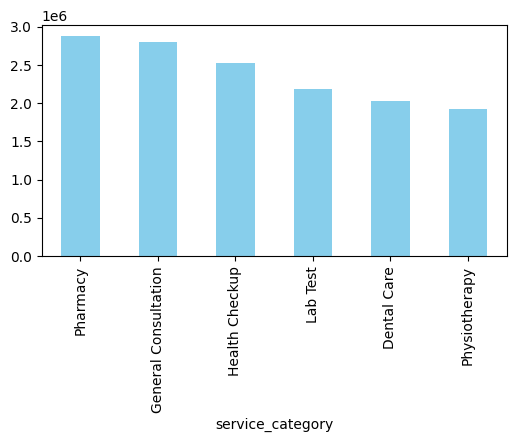
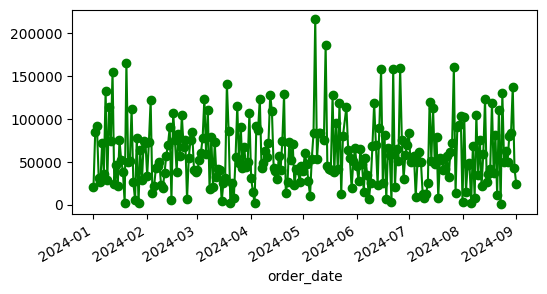

In [0]:
import io, base64, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime
from pyspark.sql.utils import AnalysisException

# --- Helpers ---
def fig_to_b64(fig):
    buf=io.BytesIO(); fig.savefig(buf,format="png",bbox_inches="tight")
    buf.seek(0); s=base64.b64encode(buf.read()).decode()
    buf.close(); plt.close(fig)
    return f"data:image/png;base64,{s}"

def load_table(name, cols):
    try:
        df = spark.table(name).toPandas()
        if set(cols).issubset(df.columns): return df
    except AnalysisException: pass
    return pd.DataFrame(columns=cols)

# --- Load Data ---
df_cat = load_table("gold_healthcare_category_sales", ["service_category","total_revenue"]).sort_values("total_revenue", ascending=False)
df_daily = load_table("gold_healthcare_daily_sales", ["order_date","daily_revenue"])
df_daily["order_date"] = pd.to_datetime(df_daily["order_date"], errors="coerce")
df_daily = df_daily.dropna(subset=["order_date"]).sort_values("order_date")

# --- KPIs ---
total_rev = float(df_cat["total_revenue"].sum()) if not df_cat.empty else 0.0
top_cat = df_cat.iloc[0]["service_category"] if not df_cat.empty else "N/A"
last_update = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# --- Charts ---
fig1_b64 = None if df_cat.empty else fig_to_b64(
    df_cat.plot(kind="bar", x="service_category", y="total_revenue", color="skyblue", legend=False, figsize=(6,3)).figure
)
fig2_b64 = None if df_daily.empty else fig_to_b64(
    df_daily.plot(x="order_date", y="daily_revenue", marker="o", color="green", legend=False, figsize=(6,3)).figure
)

# --- HTML Dashboard ---
html = f"""
<div style="font-family:Arial;padding:16px;">
  <h2>Healthcare Orders Dashboard</h2>
  <div style="color:#666;margin-bottom:12px;">Last Updated: {last_update}</div>
  <div style="display:flex;gap:20px;margin-bottom:20px;">
    <div style="flex:1;background:#f9f9f9;padding:12px;border-radius:8px;">
      <div style="font-size:12px;color:#777;">Total Revenue</div>
      <div style="font-size:22px;font-weight:700;">₹ {total_rev:,.2f}</div>
    </div>
    <div style="flex:1;background:#f9f9f9;padding:12px;border-radius:8px;">
      <div style="font-size:12px;color:#777;">Top Service</div>
      <div style="font-size:22px;font-weight:700;">{top_cat}</div>
    </div>
  </div>
  <div style="display:flex;gap:20px;">
    <div style="flex:1;">
      <h4>Revenue by Service Category</h4>
      {"<img src='"+fig1_b64+"' style='width:100%;border-radius:6px;'/>" if fig1_b64 else "<p>No data available</p>"}
    </div>
    <div style="flex:1;">
      <h4>Daily Revenue Trend</h4>
      {"<img src='"+fig2_b64+"' style='width:100%;border-radius:6px;'/>" if fig2_b64 else "<p>No data available</p>"}
    </div>
  </div>
</div>
"""
displayHTML(html)
